**Importando bibliotecas**





In [68]:
import sklearn
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import time
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

**Carregando base de dados**

In [69]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')
mnist.keys() #dict python

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

**Entendendo o dataset**

In [26]:
mnist.frame

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [27]:
mnist.data

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
mnist.details

{'id': '554',
 'name': 'mnist_784',
 'version': '1',
 'description_version': '2',
 'format': 'ARFF',
 'creator': ['Yann LeCun', 'Corinna Cortes', 'Christopher J.C. Burges'],
 'upload_date': '2014-09-29T03:28:38',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://api.openml.org/data/v1/download/52667/mnist_784.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0554/dataset_554.pq',
 'file_id': '52667',
 'default_target_attribute': 'class',
 'tag': ['Artificial Intelligence',
  'AzurePilot',
  'Computer Vision',
  'Data Sets',
  'Kaggle',
  'Machine Learning',
  'OpenML-CC18',
  'OpenML100',
  'study_1',
  'study_123',
  'study_41',
  'study_99',
  'vision'],
 'visibility': 'public',
 'minio_url': 'https://data.openml.org/datasets/0000/0554/dataset_554.pq',
 'status': 'active',
 'processing_date': '2020-11-20 20:12:09',
 'md5_checksum': '0298d579eb1b86163de7723944c7e495'}

In [29]:
mnist.url

'https://www.openml.org/d/554'

In [30]:
type(mnist)

sklearn.utils._bunch.Bunch

In [70]:
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)
#X é um dataframe pandas, y é uma serie pandas

(70000, 784)
(70000,)


In [32]:
print(y.value_counts()) # para ver quantas amostras o dataset possui por classe

class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64


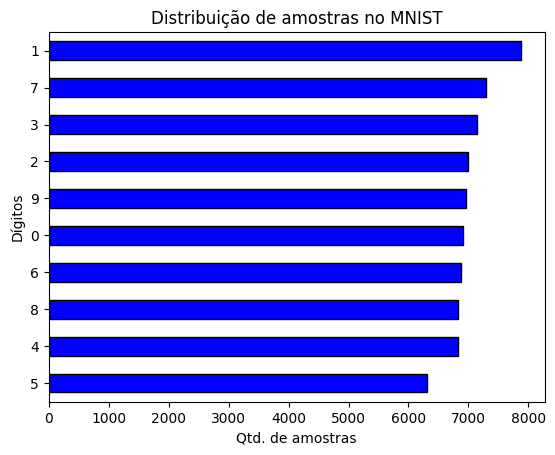

In [33]:
y_freq = y.value_counts()
y_freq.plot(kind='barh', color="blue", edgecolor="black")

plt.xlabel("Qtd. de amostras")
plt.ylabel("Dígitos")
plt.title("Distribuição de amostras no MNIST")
plt.gca().invert_yaxis()  # opcional: inverte a ordem para maior valor no topo
plt.show()

In [34]:
some_digit = X.loc[4,:]
print(some_digit)

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 4, Length: 784, dtype: int64


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

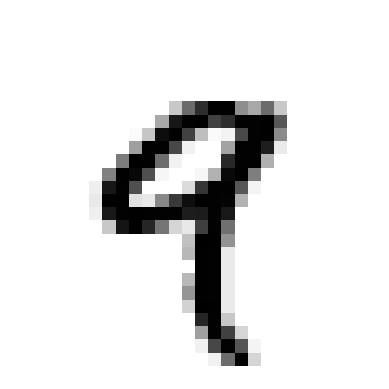

In [35]:
some_digit = X.loc[4,:] #X[0]
# converter de serie pandas para numpy (na verdade já vê a serie como um array)
some_digit_np = some_digit.to_numpy()
some_digit_image = some_digit_np.reshape(28,28)

plt.imshow(some_digit_image, cmap='binary')
plt.axis('off')

In [36]:
y[4] #verifica se y[0] é o dígito 5 mesmo

'9'

**Convertendo target para inteiro**

In [37]:
# como o label é uma string, vamos converter para número, pois os algoritmos ML trabalham com números
y = y.astype(np.uint8) # unsigned int de 1 byte, o famoso unsigned char do C

**Separando base de treino e validação**

In [71]:
# o dataset MNIST já é separado em conjunto de treino e teste, onde o conjunto de treino está embaralhado (shuffle),
# o que é bom neste caso
X_train, X_test, y_train, y_test = X[:56000], X[56000:], y[:56000], y[56000:]

class
1    1569
7    1483
2    1430
3    1413
9    1399
4    1376
0    1373
8    1365
6    1339
5    1253
Name: count, dtype: int64


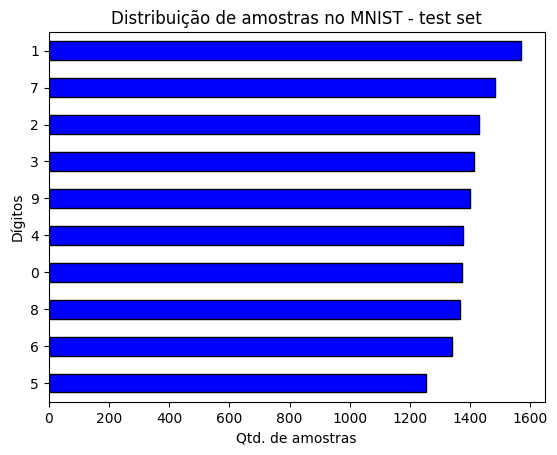

In [39]:
print(y_test.value_counts())
y_freq = y_test.value_counts()
y_freq.plot(kind='barh', color="blue", edgecolor="black")

plt.xlabel("Qtd. de amostras")
plt.ylabel("Dígitos")
plt.title("Distribuição de amostras no MNIST - test set")
plt.gca().invert_yaxis()  # opcional: inverte a ordem para maior valor no topo
plt.show()

**Treinando RandomForestClassifier com a base mnist**

In [40]:
# Inicializar o modelo RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Tempo de treinamento com a base completa
%time rf_model.fit(X_train, y_train)

CPU times: user 50.8 s, sys: 26.8 ms, total: 50.9 s
Wall time: 51.1 s


RandomForestClassifier(random_state=42)

**Avalinando o modelo**

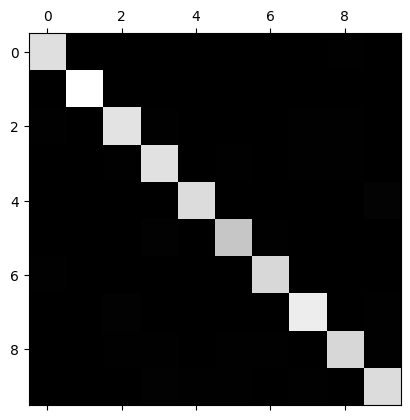

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1373
           1       0.99      0.99      0.99      1569
           2       0.97      0.97      0.97      1430
           3       0.96      0.97      0.97      1413
           4       0.98      0.97      0.98      1376
           5       0.97      0.96      0.97      1253
           6       0.97      0.98      0.98      1339
           7       0.97      0.97      0.97      1483
           8       0.96      0.96      0.96      1365
           9       0.96      0.95      0.96      1399

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [41]:
# make predictions
yhat = rf_model.predict(X_test)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))

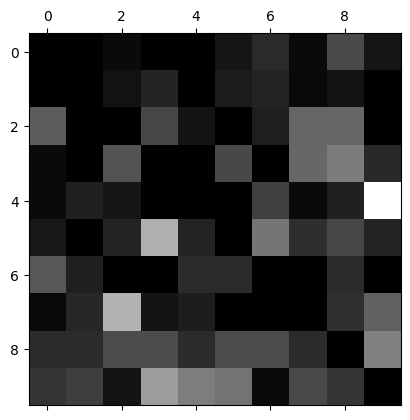

In [42]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums # dividir cada valor na matriz pelo número de imagens na classe correspondente (ERRO)

np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

**Aplicando PCA na base de dados**

In [62]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(70000, 154)


**Separando novamente a base de dados**


In [63]:
X_train, X_test, y_train, y_test = X_pca[:56000], X_pca[56000:], y[:56000], y[56000:]

**Treinando o RandomForestClassifier com a base reduzida**

In [45]:
%time rf_model.fit(X_train, y_train)

CPU times: user 2min 1s, sys: 56.2 ms, total: 2min 1s
Wall time: 2min 3s


RandomForestClassifier(random_state=42)

**Testando com normalização**

In [46]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
X_train, X_test, y_train, y_test = X_pca[:56000], X_pca[56000:], y[:56000], y[56000:]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
# Inicializar o modelo RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

(70000, 154)


In [47]:
%time rf_model.fit(X_train_scaled, y_train)

CPU times: user 2min 9s, sys: 146 ms, total: 2min 9s
Wall time: 2min 10s


RandomForestClassifier(random_state=42)

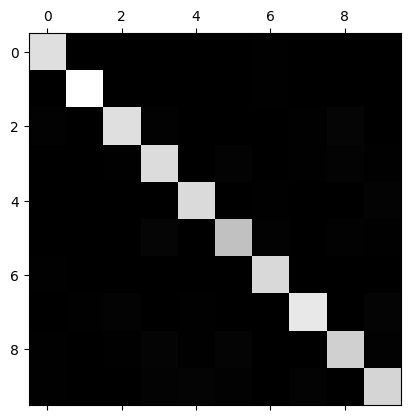

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1373
           1       0.98      0.99      0.98      1569
           2       0.95      0.94      0.95      1430
           3       0.93      0.94      0.94      1413
           4       0.96      0.96      0.96      1376
           5       0.94      0.93      0.94      1253
           6       0.96      0.98      0.97      1339
           7       0.96      0.95      0.95      1483
           8       0.93      0.92      0.93      1365
           9       0.94      0.92      0.93      1399

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000



In [48]:
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.astype(np.float64))
# make predictions
yhat = rf_model.predict(X_test_scaled)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))

**Avaliando o modelo**

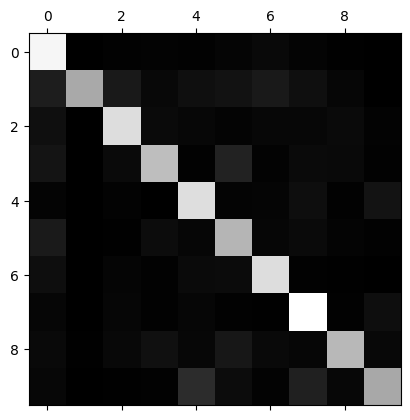

              precision    recall  f1-score   support

           0       0.65      0.89      0.75      1373
           1       0.99      0.54      0.70      1569
           2       0.77      0.77      0.77      1430
           3       0.76      0.67      0.71      1413
           4       0.68      0.80      0.74      1376
           5       0.61      0.72      0.66      1253
           6       0.75      0.82      0.78      1339
           7       0.71      0.86      0.78      1483
           8       0.80      0.67      0.73      1365
           9       0.76      0.60      0.67      1399

    accuracy                           0.73     14000
   macro avg       0.75      0.73      0.73     14000
weighted avg       0.75      0.73      0.73     14000



In [49]:
# make predictions
yhat = rf_model.predict(X_test)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))

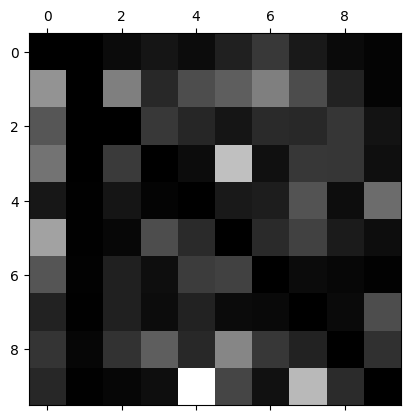

In [50]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums # dividir cada valor na matriz pelo número de imagens na classe correspondente (ERRO)

np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

**Treinando a base com o modelo de regressão lógistica**

In [51]:
log_reg_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", random_state=42)

# Treinar o modelo base completa
%time log_reg_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 20.8 s, sys: 17.6 ms, total: 20.9 s
Wall time: 11.4 s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial', random_state=42)

**Avaliando Modelo**

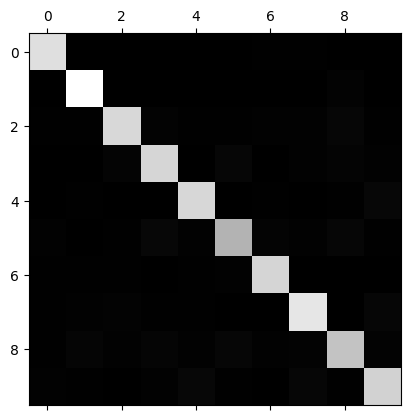

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1373
           1       0.95      0.98      0.96      1569
           2       0.93      0.91      0.92      1430
           3       0.91      0.91      0.91      1413
           4       0.92      0.94      0.93      1376
           5       0.91      0.86      0.88      1253
           6       0.94      0.95      0.95      1339
           7       0.92      0.93      0.93      1483
           8       0.89      0.86      0.87      1365
           9       0.90      0.90      0.90      1399

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [52]:
# make predictions
yhat = log_reg_model.predict(X_test)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))

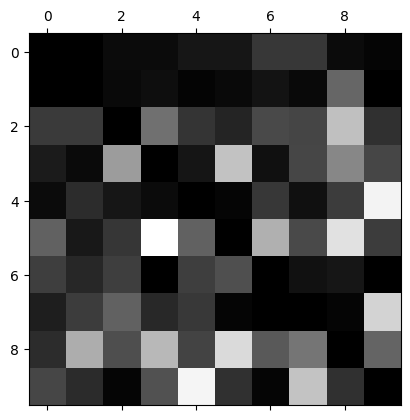

In [53]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums # dividir cada valor na matriz pelo número de imagens na classe correspondente (ERRO)

np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

**Regressão lógistica na base reduzida**

In [54]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
X_train, X_test, y_train, y_test = X_pca[:56000], X_pca[56000:], y[:56000], y[56000:]
# Treino com base reduzida
%time log_reg_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 22.1 s, sys: 38.2 ms, total: 22.1 s
Wall time: 12.1 s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial', random_state=42)

**Avaliando modelo**


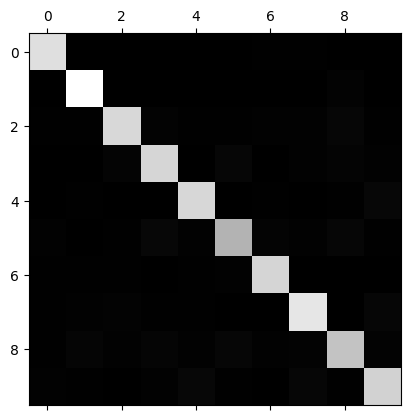

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1373
           1       0.95      0.98      0.96      1569
           2       0.93      0.91      0.92      1430
           3       0.91      0.91      0.91      1413
           4       0.92      0.94      0.93      1376
           5       0.91      0.86      0.88      1253
           6       0.94      0.95      0.95      1339
           7       0.92      0.93      0.93      1483
           8       0.89      0.86      0.87      1365
           9       0.90      0.90      0.90      1399

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [55]:
# make predictions
yhat = log_reg_model.predict(X_test)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))

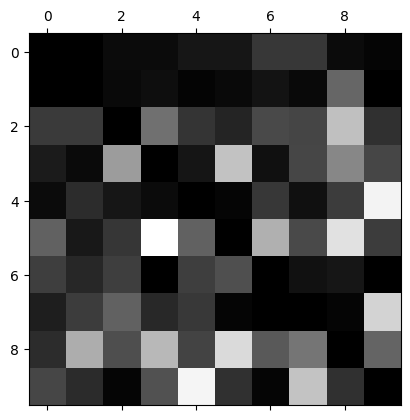

In [56]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums # dividir cada valor na matriz pelo número de imagens na classe correspondente (ERRO)

np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

**Testando com outros modelos**


In [64]:
model_sgd = SGDClassifier()
%time model_sgd.fit(X_train, y_train)

CPU times: user 33.2 s, sys: 22.8 ms, total: 33.2 s
Wall time: 33.3 s


SGDClassifier()

In [ ]:
2m e 8s
33.2 S

In [72]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
%time gnb.fit(X_train, y_train)

CPU times: user 712 ms, sys: 195 ms, total: 906 ms
Wall time: 908 ms


GaussianNB()

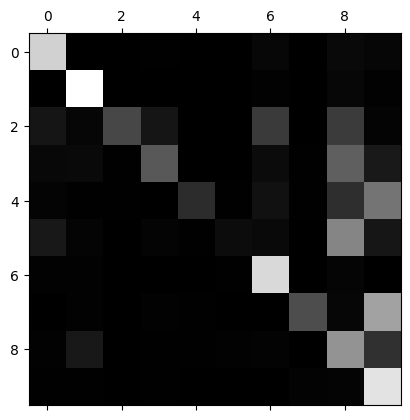

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1373
           1       0.83      0.95      0.88      1569
           2       0.92      0.29      0.44      1430
           3       0.72      0.37      0.49      1413
           4       0.88      0.19      0.32      1376
           5       0.61      0.06      0.11      1253
           6       0.66      0.94      0.78      1339
           7       0.89      0.30      0.45      1483
           8       0.29      0.63      0.40      1365
           9       0.37      0.95      0.53      1399

    accuracy                           0.56     14000
   macro avg       0.69      0.56      0.52     14000
weighted avg       0.70      0.56      0.53     14000



In [73]:
# make predictions
yhat = gnb.predict(X_test)

conf_mx = confusion_matrix(y_test, yhat)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

print(classification_report(y_test,yhat))